In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("Ice_cream selling data.csv")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [7]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [8]:
X=df[["Temperature (°C)"]]
y=df["Ice Cream Sales (units)"]

In [9]:
model = LinearRegression()

In [10]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [11]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
model.intercept_

np.float64(17.139213127718417)

In [13]:
model.coef_

array([-1.14658686])

In [14]:
y_train_pred=model.predict(xtrain)

In [15]:
error1=ytrain-y_train_pred
error1

12    -8.342361
4     11.042195
34    -7.068653
8     -0.976452
3     15.872002
6      1.932092
40     9.382303
41     3.593455
46    22.127929
15    -7.702291
9      0.099389
16   -11.795178
24   -13.772684
33    -6.589195
30   -11.361582
0     19.358084
43    12.790464
32    -5.903007
5      8.899652
29   -14.626954
11    -1.638915
36     2.050464
1     12.572596
21   -16.280474
2     17.412088
37    -1.324117
35    -3.968282
23   -15.036675
39     6.438895
10    -6.903557
22   -13.963744
18   -12.701567
48    29.992774
20   -16.852044
7      4.692827
42    11.805034
14    -6.427765
28   -14.424269
38     7.597522
Name: Ice Cream Sales (units), dtype: float64

In [16]:
y_test_pred=model.predict(xtest)

In [17]:
error2=ytest-y_test_pred
error2

13    -9.211915
45     4.951767
47    15.298626
44    15.913046
17    -8.632935
27   -13.651095
26   -15.346085
25   -11.718252
31   -10.159407
19   -12.637140
Name: Ice Cream Sales (units), dtype: float64

In [18]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score
y_pred_train=model.predict(xtrain)
score=r2_score(ytrain,y_pred_train)
score

0.06579063815950037

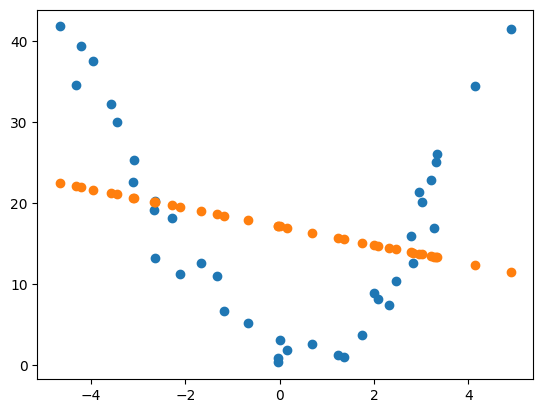

In [19]:
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,y_train_pred)

In [20]:
mae = mean_absolute_error(ytest, y_test_pred)
rmse = root_mean_squared_error(ytest, y_test_pred)

In [21]:
rmse

12.219913714640208

In [22]:
mae

11.752026695440602